In [1]:
""" Created on November 13, 2023 // @author: Sarah Shi """

import os
import numpy as np
import pandas as pd

import sys
sys.path.append('../../src')
import mineralML as mm

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## mineralML Mapping Quickstart

This notebook shows **how to load and run your quantitative EDS data through mineralML** with an example gabbroic nodule from the Galapagos: `09g3`. These data are from Gleeson et al., 2024 (find the paper here: https://doi.org/10.1093/petrology/egaf031) in this GitHub repository (https://github.com/gleesonm1/GleesonEtAl_JPet_2024_supplement/tree/main/Code_Figures/Data/LargeScaleMaps/Gabbro%20Samples). Please refer to the paper for more information about this sample. 

This is a four step process: 
1. Load a directory containing all your CSVs of mapped chemical data with `load_df` (or `pd.read_csv` directly).
2. [Optional] Convert the input from element to oxide wt%.
3. Predict the mineral class with mineralML.
3. Plot the phase map, plot phase_counts, and plot probability histograms

I have conveniently (I hope!) wrapped all of these bits into one function, called ``mm.run_sample``.

We loaded in the ``mineralML`` Python package as ``mm``. ``mineralML`` has trained machine learning models for classifying minerals. This implementation aims to get your electron microprobe or quantitative EDS compositions classified and processed. We remove some degrees of freedom to simplify the process as much as possible. The minerals considered for this study include: Amphibole, Apatite, Biotite, Calcite, Chlorite, Epidote, Feldspar (KFeldspar and Plagioclase), Garnet, Glass, Kalsilite, Leucite, Melilite, Muscovite, Nepheline, Olivine, Pyroxene (Clinopyroxene, Orthopyroxene, Sodic Pyroxenes), Quartz, Rhombohedral_Oxides (Hematite-Ilmenite), Rutile, Serpentine, Spinels (Magnetite-Spinel), Titanite, Tourmaline, and Zircon. 

One CSV file containing your electron microprobe analyses in oxide weight percentages is necessary. Find an example [here](https://github.com/sarahshi/mineralML/blob/main/docs/examples/09g3). The nominally necessary oxides are $SiO_2$, $TiO_2$, $Al_2O_3$, $FeO_t$, $MnO$, $MgO$, $CaO$, $Na_2O$, $K_2O$, $Cr_2O_3$, and $P_2O_5$. For the oxides not analyzed for specific minerals, the preprocessing will fill in the nan values as 0. 

## Supervised Machine Learning for SEM-EDS Data

## Load and prepare data for analysis

Here, we will work with data that are in elemental weight percent. This means that we will have to do a conversion to oxide weight perecent.

In [2]:
# Find your directory of mapped mineral data, stored in Maps/09g3. 
# This code identifies any file with CSV and appends it to the map. 

base = "Maps"
map_dirs = []
for root, subdirs, files in os.walk(base):
    # Skip any path that includes 'Ignore' in its folder names
    if "Ignore" in root.split(os.sep):
        continue
    
    if any(f.lower().endswith(".csv") for f in files):
        map_dirs.append(root)

print(map_dirs)

['Maps/09g3']


## mm.run_sample

We will use ``mm.run_sample`` which will return all you need! 

In [3]:
# Inspect the inputs and outputs of mm.run_sample
help(mm.run_sample)

Help on function run_sample in module mineralML.mapping:

run_sample(sample_input, n_iterations=50, prob_threshold=0.6, min_frac_to_show=0.01, units='element_wt%', top_k=None, phases=None, return_everything=True, show=True, compute_components=False, components_spec=None)
    Load, convert, predict, plot for one folder of CSV maps.
    
    Parameters:
        sample_input (str | Path | dict): Either a directory path containing element CSV maps
            or a preloaded dict of oxide maps.
        n_iterations (int): MC forward passes for prediction.
        prob_threshold (float): Set label to NaN where max probability < threshold.
        min_frac_to_show (float): phases phases with fraction ≥ this value.
        top_k (int|None): Cap displayed phases after filtering.
        phases (list[str]|None): Explicit phases to plot (None->auto).
        return_everything (bool): If True, return dict of intermediates.
        show (bool): If True, call plt.show().
    
    Returns:
        fi

[ok] Mg Wt%Montaged Map Data.csv  →  Mg  (329, 283)
[ok] Ca Wt%Montaged Map Data.csv  →  Ca  (329, 283)
[ok] Al Wt%Montaged Map Data.csv  →  Al  (329, 283)
[ok] Fe Wt%Montaged Map Data.csv  →  Fe  (329, 283)
[ok] Na Wt%Montaged Map Data.csv  →  Na  (329, 283)
[ok] Mn Wt%Montaged Map Data.csv  →  Mn  (329, 283)
[ok] Cr Wt%Montaged Map Data.csv  →  Cr  (329, 283)
[ok] Ti Wt%Montaged Map Data.csv  →  Ti  (329, 283)
[ok] Si Wt%Montaged Map Data.csv  →  Si  (329, 283)
[ok] K Wt%Montaged Map Data.csv  →  K  (329, 283)


/Users/sarahcshi/Documents/GitHub/mineralML/docs/examples/../../src/mineralML/supervised.py:154: UserWarning: The column 'ZrO2' was missing and has been filled with NaN.
  df = prep_df_nn(df)
/Users/sarahcshi/Documents/GitHub/mineralML/docs/examples/../../src/mineralML/supervised.py:154: UserWarning: The column 'Mineral' was missing and has been filled with NaN.
  df = prep_df_nn(df)
/Users/sarahcshi/Documents/GitHub/mineralML/docs/examples/../../src/mineralML/supervised.py:154: UserWarning: Some non-numeric values were found in the oxides columns and have been coerced to NaN.
  df = prep_df_nn(df)


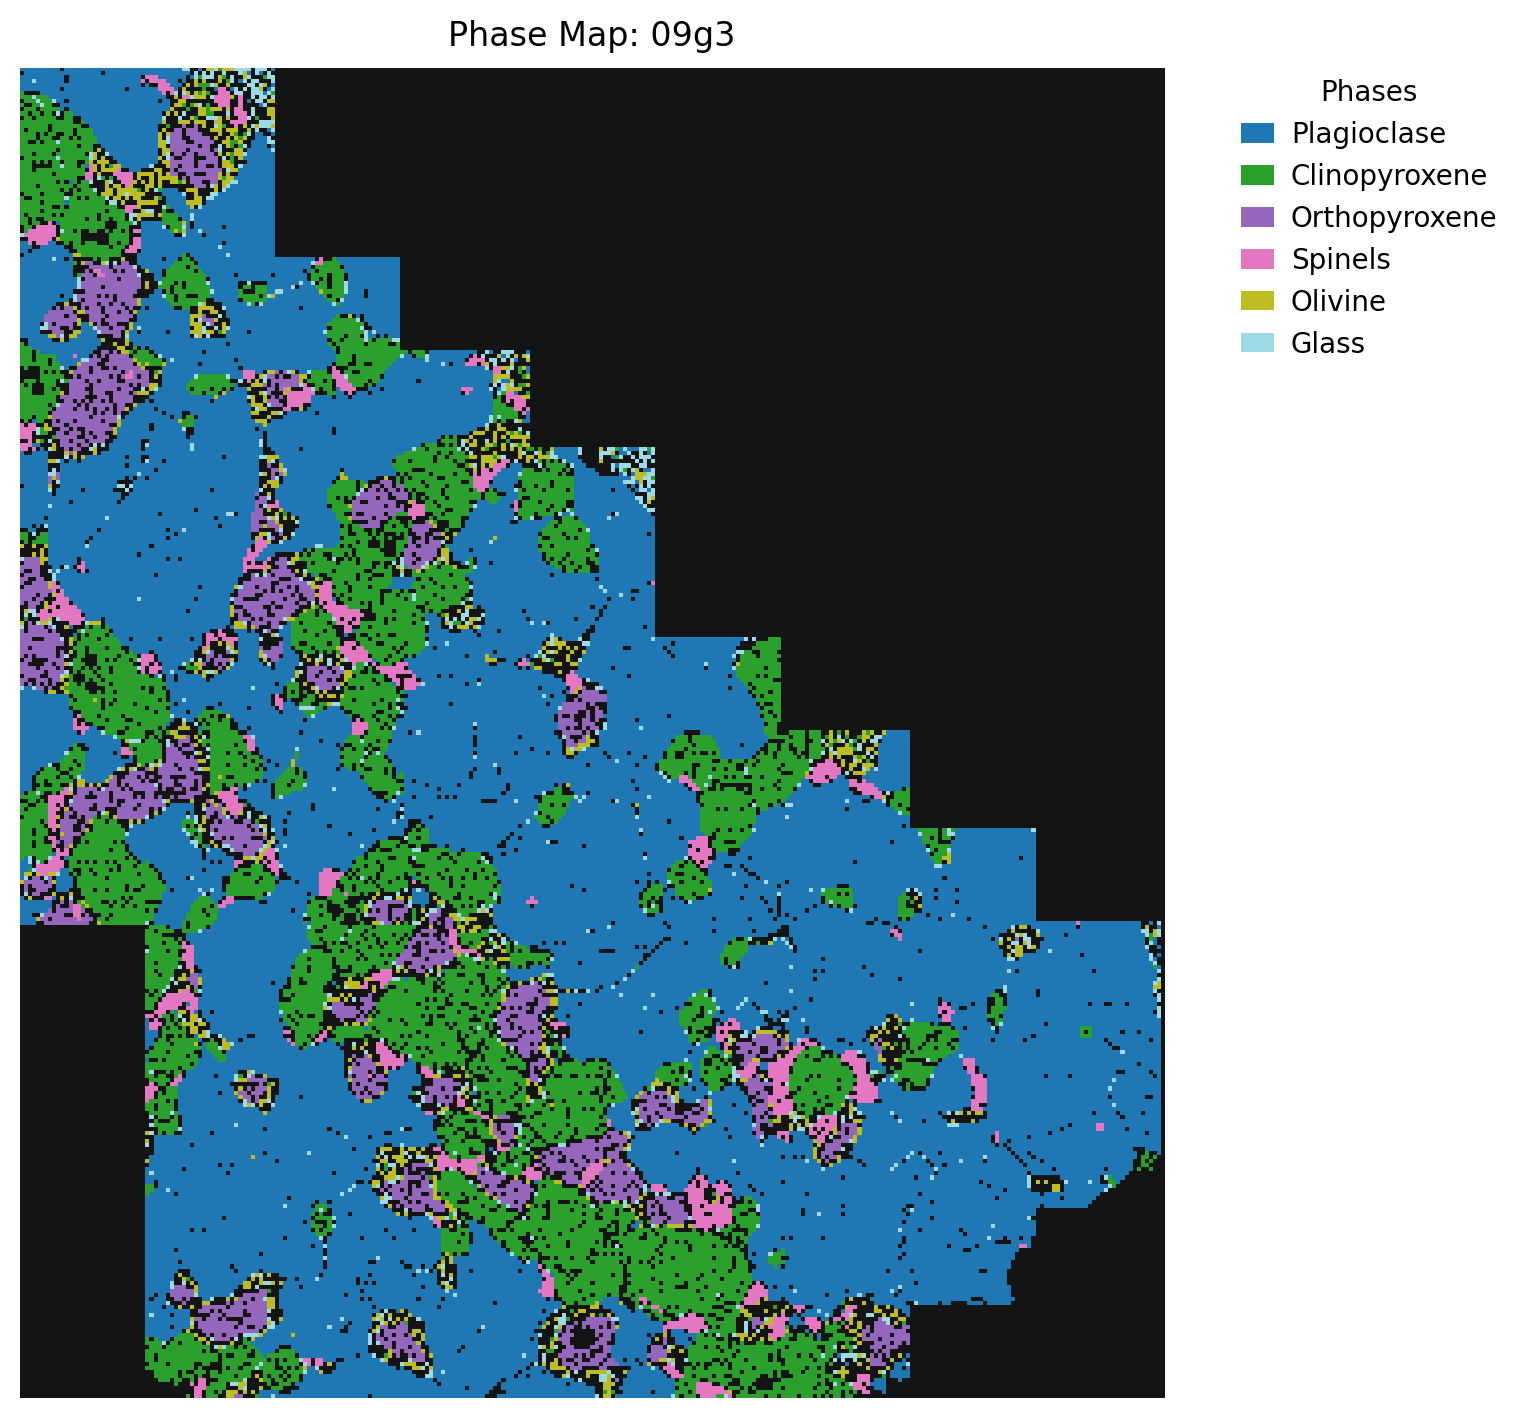

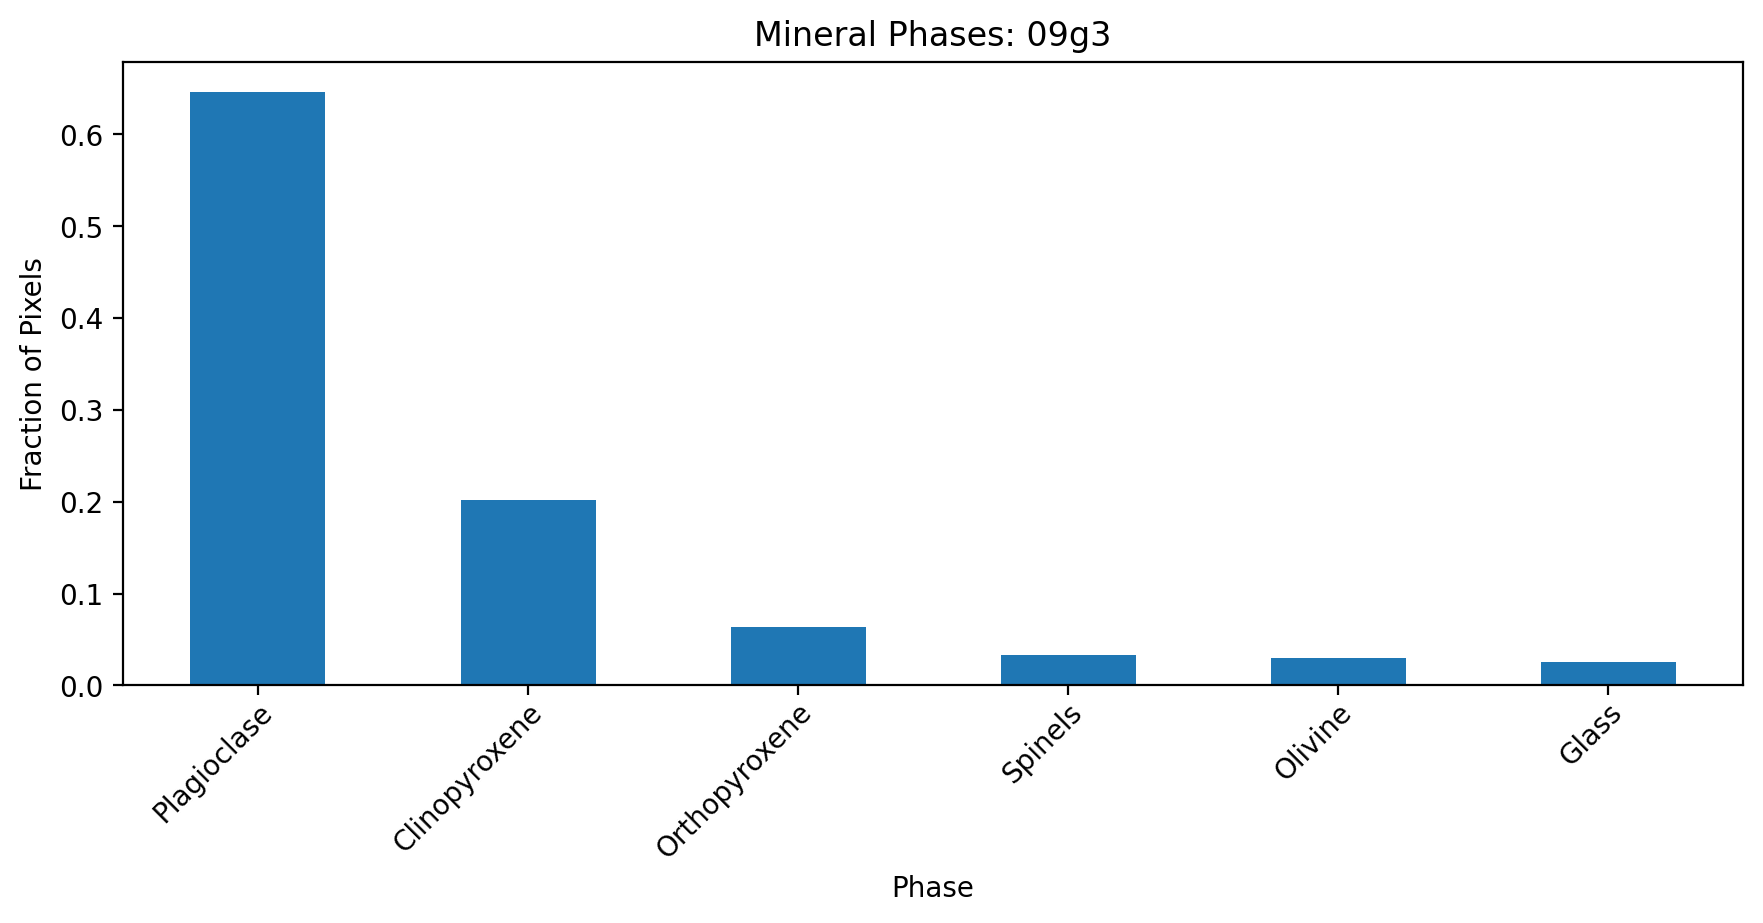

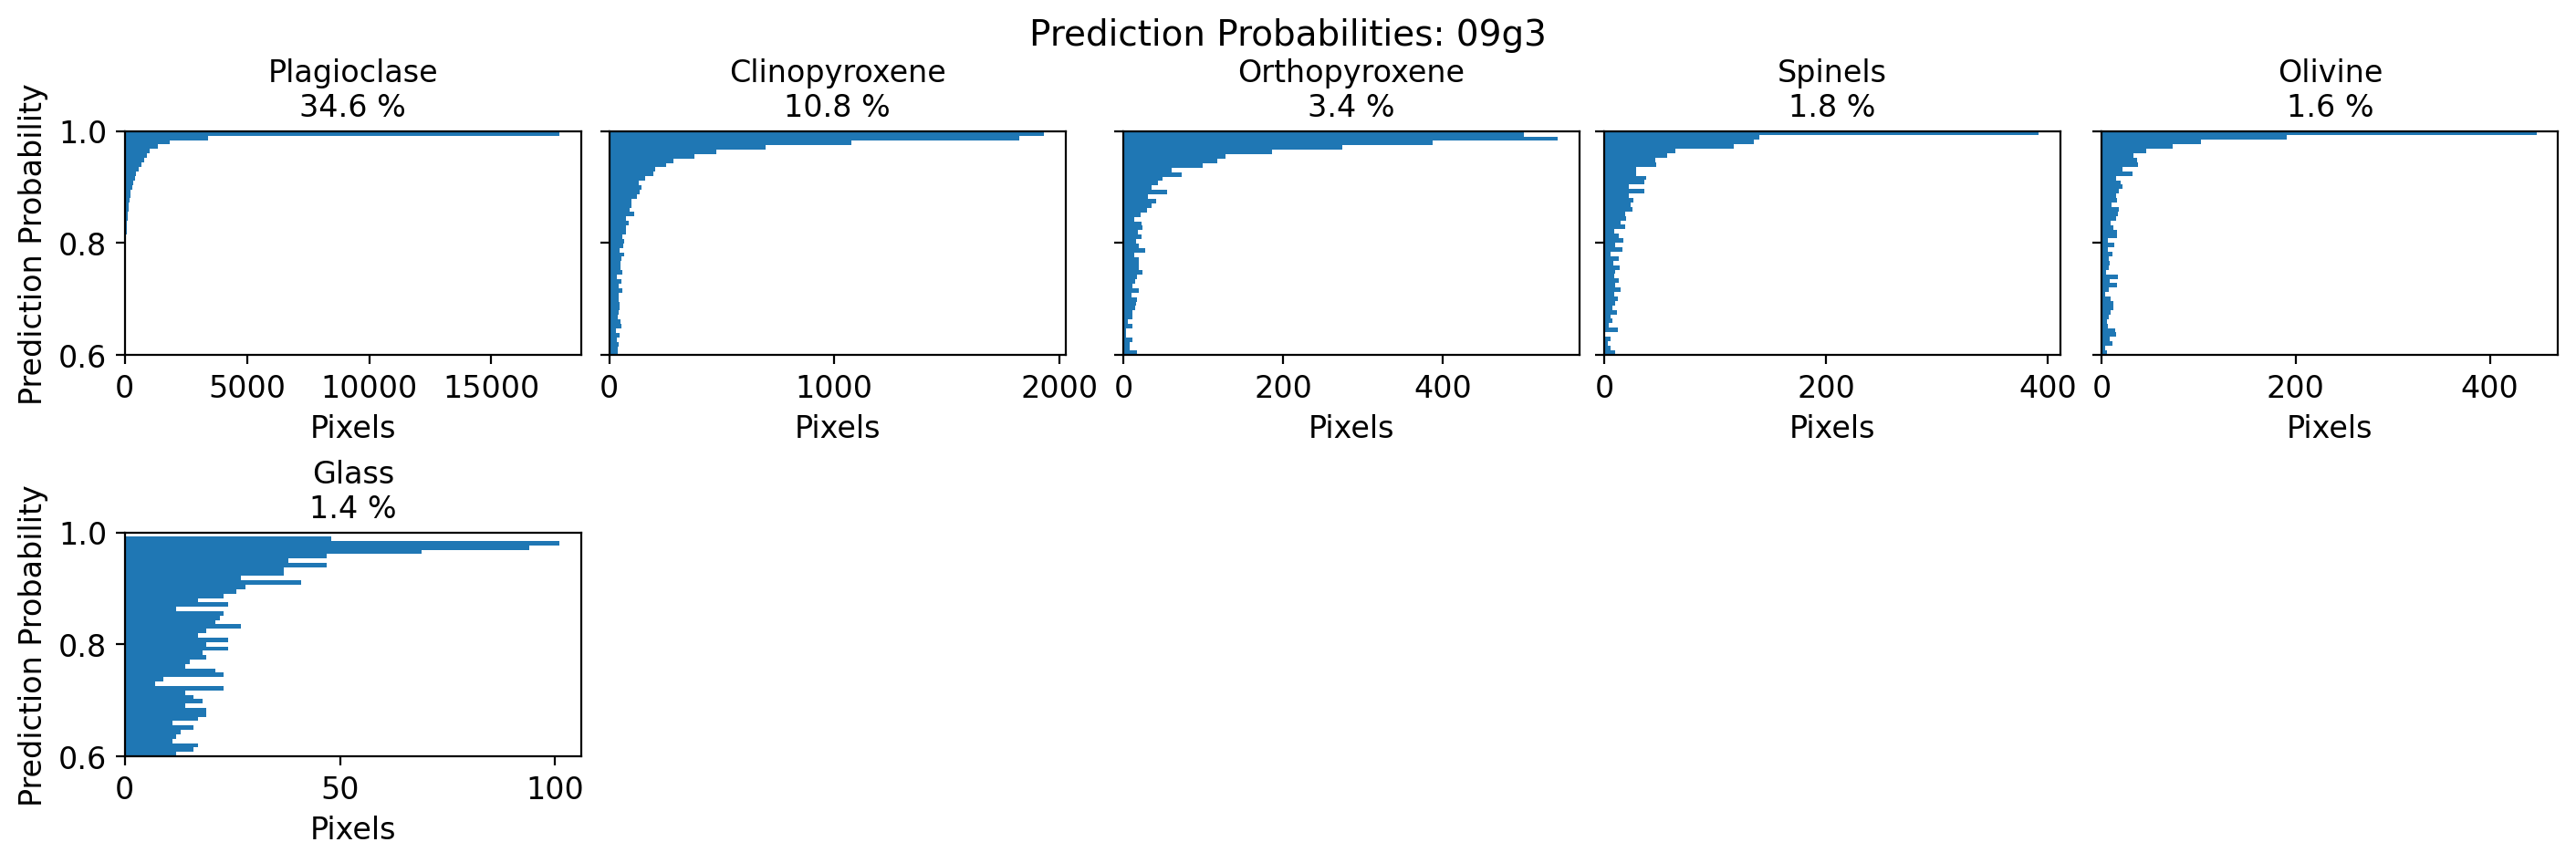

In [4]:
# Here is our all in one function! Read the inputs and outputs provided above. 
 
output = mm.run_sample(map_dirs[0], # providing the directory of interest. alternatively, you can provide the preloaded dictionary of oxides. 
                       prob_threshold=0.6, # providing a probability threshold. here, i only want values with >= 0.6 (60%) probability.
                       min_frac_to_show=0.01, # provide a minimum pixel fraction for the phase to be displayed
                       units='element_wt%', # provide the unit. can choose 'element_wt%' or 'oxide_wt%'
                       phases=['Plagioclase', 'Clinopyroxene', 'Orthopyroxene', 'Spinels', 'Olivine', 'Glass'], # phases of interest
                       return_everything=True, # whether or not to return all the potential outputs. 
                       compute_components=True, # whether or not to calculate mineral components (XAn in plag, XMg in cpx, XFo in Olivine, etc.)
                       show=True)


In [5]:
# Inspect what is in the outputs
output.keys()

dict_keys(['figs', 'shape', 'oxide_maps', 'df_ordered', 'df_pred', 'prob_matrix', 'mineral_map', 'prob_map', 'kept_phases', 'component_maps', 'component_frames'])

Let's say you now want to work with these data in dataframe form rather than dictionary form. How would you do this? 

In [6]:
# Pull the dataframe of predictions
df_pred = output['df_pred']
display(df_pred)


,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,P2O5,Cr2O3,Predict_Mineral,Submineral,Predict_Probability,Second_Predict_Mineral,Second_Predict_Probability
0,49.263735,0.246671,31.267656,-0.141366,-0.133547,-0.041928,11.384471,3.906129,0.287173,NaN,0.206763,Plagioclase,Labradorite,0.985908,Muscovite,0.012363
1,52.781465,1.223476,29.213528,1.751936,-0.008407,0.353991,13.811718,3.613949,0.326185,NaN,0.009850,Plagioclase,Labradorite,0.998238,Glass,0.000599
2,49.582496,-0.666395,31.217623,0.669667,0.312345,0.135481,13.362425,2.559899,0.404478,NaN,-0.008271,Plagioclase,Bytownite,0.990372,Glass,0.009049
3,49.766286,-0.061016,30.748715,-0.049472,0.052490,-0.063224,13.924789,3.722859,0.031619,NaN,-0.244754,Plagioclase,Labradorite,0.997895,Glass,0.001227
4,50.775667,0.283931,29.405951,0.363973,0.161280,0.434312,12.246722,2.495524,0.260420,NaN,0.922368,Plagioclase,Bytownite,0.980114,Glass,0.019249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93102,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,Rutile,NaN,0.324258,Chlorite,0.279887
93103,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,Rutile,NaN,0.324258,Chlorite,0.279887
93104,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,Rutile,NaN,0.324257,Chlorite,0.279887
93105,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,Rutile,NaN,0.324257,Chlorite,0.279887


### We can do some more with mineralML now. Let's plot all the feldspars, pyroxenes, and spinels in ternary space. 


In [7]:
# Here are all our feldspars 
fspars = df_pred[df_pred.Predict_Mineral == 'Plagioclase']
display('Feldspars:', fspars)

# Here are all our pyroxenes 
pxs_names = ['Clinopyroxene', 'Orthopyroxene']
pxs = df_pred[df_pred.Predict_Mineral.isin(pxs_names)]
display('Pyroxenes:', pxs)

# Here are all our spinels 
sp_names = ['Spinels']
sps = df_pred[df_pred.Predict_Mineral.isin(sp_names)]
display('Spinels:', sps)



'Feldspars:'

,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,P2O5,Cr2O3,Predict_Mineral,Submineral,Predict_Probability,Second_Predict_Mineral,Second_Predict_Probability
0,49.263735,0.246671,31.267656,-0.141366,-0.133547,-0.041928,11.384471,3.906129,0.287173,NaN,0.206763,Plagioclase,Labradorite,0.985908,Muscovite,0.012363
1,52.781465,1.223476,29.213528,1.751936,-0.008407,0.353991,13.811718,3.613949,0.326185,NaN,0.009850,Plagioclase,Labradorite,0.998238,Glass,0.000599
2,49.582496,-0.666395,31.217623,0.669667,0.312345,0.135481,13.362425,2.559899,0.404478,NaN,-0.008271,Plagioclase,Bytownite,0.990372,Glass,0.009049
3,49.766286,-0.061016,30.748715,-0.049472,0.052490,-0.063224,13.924789,3.722859,0.031619,NaN,-0.244754,Plagioclase,Labradorite,0.997895,Glass,0.001227
4,50.775667,0.283931,29.405951,0.363973,0.161280,0.434312,12.246722,2.495524,0.260420,NaN,0.922368,Plagioclase,Bytownite,0.980114,Glass,0.019249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92980,50.751835,0.053460,30.892806,0.040494,-0.461759,0.181496,13.219259,4.255093,0.562793,NaN,0.125117,Plagioclase,Labradorite,0.930480,Muscovite,0.067365
92981,47.055855,0.435257,28.540332,0.088852,-0.089822,0.027772,10.548025,3.540654,0.550766,NaN,0.032374,Plagioclase,Labradorite,0.994920,Glass,0.001718
92982,49.572227,0.371584,32.248626,0.873017,-0.285326,0.130899,12.215584,4.380849,0.471066,NaN,0.514502,Plagioclase,Labradorite,0.958324,Muscovite,0.039983
92983,49.374082,-0.392758,32.780453,0.389758,0.339789,0.275332,13.295722,4.352765,0.428836,NaN,0.269782,Plagioclase,Labradorite,0.998443,Glass,0.001151


'Pyroxenes:'

,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,P2O5,Cr2O3,Predict_Mineral,Submineral,Predict_Probability,Second_Predict_Mineral,Second_Predict_Probability
49,46.703956,2.306829,8.091728,7.608155,0.179336,10.411849,18.795262,2.432519,0.532825,NaN,0.203853,Clinopyroxene,Diopside,0.913901,Amphibole,0.056315
610,48.659501,1.695958,7.334367,7.926977,-0.333935,10.416438,17.438423,2.285797,1.183322,NaN,0.106932,Clinopyroxene,Diopside,0.690528,Serpentine,0.223714
616,48.778790,1.189971,2.368374,9.717480,-0.178262,19.703388,16.359033,0.808957,0.195681,NaN,0.046046,Clinopyroxene,Augite,0.734395,Serpentine,0.181102
626,43.817565,1.304287,4.129765,5.646358,-0.037404,11.766227,22.258578,1.406237,0.008721,NaN,0.322146,Clinopyroxene,Wollastonite,0.979505,Serpentine,0.005956
900,48.447279,1.397534,3.416259,9.859029,0.064421,16.668941,17.343585,1.357627,0.303317,NaN,0.192969,Clinopyroxene,Augite,0.959646,Serpentine,0.021057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93026,48.531633,1.086635,6.924229,5.679027,0.897636,13.753107,20.414549,0.316232,0.073446,NaN,0.035749,Clinopyroxene,Diopside,0.925462,Amphibole,0.057292
93027,46.290230,1.380040,7.945115,7.235223,0.274338,11.797178,19.396081,0.955456,-0.142047,NaN,0.399850,Clinopyroxene,Diopside,0.510463,Amphibole,0.384303
93028,48.117886,0.149082,8.696416,5.671712,0.169030,13.621192,20.402754,1.625494,0.058249,NaN,-0.174842,Clinopyroxene,Diopside,0.940147,Amphibole,0.047456
93029,46.544554,0.287509,7.870030,6.250091,0.117071,12.650849,19.429830,-0.016576,0.135432,NaN,-0.335588,Clinopyroxene,Diopside,0.954199,Quartz,0.022454


'Spinels:'

,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,P2O5,Cr2O3,Predict_Mineral,Submineral,Predict_Probability,Second_Predict_Mineral,Second_Predict_Probability
597,-0.541988,-0.226758,59.577095,22.761509,0.261160,16.543655,0.178530,-0.327176,-0.002519,NaN,0.596073,Spinels,Spinels,0.998390,Chlorite,0.000973
598,0.328607,0.192199,60.074062,22.531151,-0.581629,16.206175,-0.071793,0.404589,-0.041741,NaN,1.762033,Spinels,Spinels,0.923457,Chlorite,0.050876
599,0.419032,-0.416014,59.597162,20.757558,-0.198876,16.481142,-0.157663,0.094932,0.114364,NaN,1.412415,Spinels,Spinels,0.935769,Chlorite,0.054041
879,-0.283622,-0.329943,58.807763,21.683161,0.131220,15.814531,-0.270460,0.445707,0.113306,NaN,0.450210,Spinels,Spinels,0.946745,Chlorite,0.039709
881,0.082835,-0.143675,59.493695,20.211482,-0.144503,15.916152,0.157949,-0.566213,0.121678,NaN,1.429695,Spinels,Spinels,0.891525,Chlorite,0.104549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92992,-0.972727,0.199933,61.268541,19.730463,0.777305,16.862860,0.416785,0.532657,0.209819,NaN,1.072017,Spinels,Spinels,0.998645,Apatite,0.001290
92993,-0.754471,-0.316257,58.986714,21.457833,0.307136,14.984843,-0.049067,-0.382976,-0.506373,NaN,0.888524,Spinels,Spinels,0.794626,Chlorite,0.190608
92994,-0.476960,0.326008,59.845682,20.725138,0.091979,16.190988,0.066551,0.394945,0.127746,NaN,0.985187,Spinels,Spinels,0.977362,Chlorite,0.018340
92995,5.724564,0.254216,55.985948,19.883002,-0.329296,15.163671,0.563598,1.013702,0.281037,NaN,1.044170,Spinels,Spinels,0.755366,Chlorite,0.123574


Plot these feldspars, pyroxenes, and spinels! 

,Sample Name,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,...,P_cat_8ox,Cr_cat_8ox,Mineral,Source,Cation_Sum,M_site,T_site,An,Ab,Or
0,NaN,49.263735,0.246671,31.267656,0.000000,0.000000,0.000000,11.384471,3.906129,0.287173,...,0.0,0.007666,NaN,NaN,4.999206,0.944346,4.038491,0.605725,0.376083,0.018192
1,NaN,52.781465,1.223476,29.213528,1.751936,0.000000,0.353991,13.811718,3.613949,0.326185,...,0.0,0.000347,NaN,NaN,5.005620,0.989984,3.885500,0.665953,0.315321,0.018726
2,NaN,49.582496,0.000000,31.217623,0.669667,0.312345,0.135481,13.362425,2.559899,0.404478,...,0.0,0.000000,NaN,NaN,4.973277,0.918395,4.007258,0.723219,0.250716,0.026065
3,NaN,49.766286,0.000000,30.748715,0.000000,0.052490,0.000000,13.924789,3.722859,0.031619,...,0.0,0.000000,NaN,NaN,5.019679,1.028596,3.989021,0.672721,0.325460,0.001819
4,NaN,50.775667,0.283931,29.405951,0.363973,0.161280,0.434312,12.246722,2.495524,0.260420,...,0.0,0.033946,NaN,NaN,4.923061,0.851499,3.977005,0.717332,0.264506,0.018162
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92980,NaN,50.751835,0.053460,30.892806,0.040494,0.000000,0.181496,13.219259,4.255093,0.562793,...,0.0,0.004514,NaN,NaN,5.053574,1.055605,3.977727,0.612308,0.356653,0.031038
92981,NaN,47.055855,0.435257,28.540332,0.088852,0.000000,0.027772,10.548025,3.540654,0.550766,...,0.0,0.001276,NaN,NaN,4.987109,0.940703,4.023037,0.598951,0.363812,0.037237
92982,NaN,49.572227,0.371584,32.248626,0.873017,0.000000,0.130899,12.215584,4.380849,0.471066,...,0.0,0.018501,NaN,NaN,5.065717,1.008939,3.983479,0.590014,0.382896,0.027090
92983,NaN,49.374082,0.000000,32.780453,0.389758,0.339789,0.275332,13.295722,4.352765,0.428836,...,0.0,0.009652,NaN,NaN,5.089961,1.051290,3.982672,0.613189,0.363263,0.023548


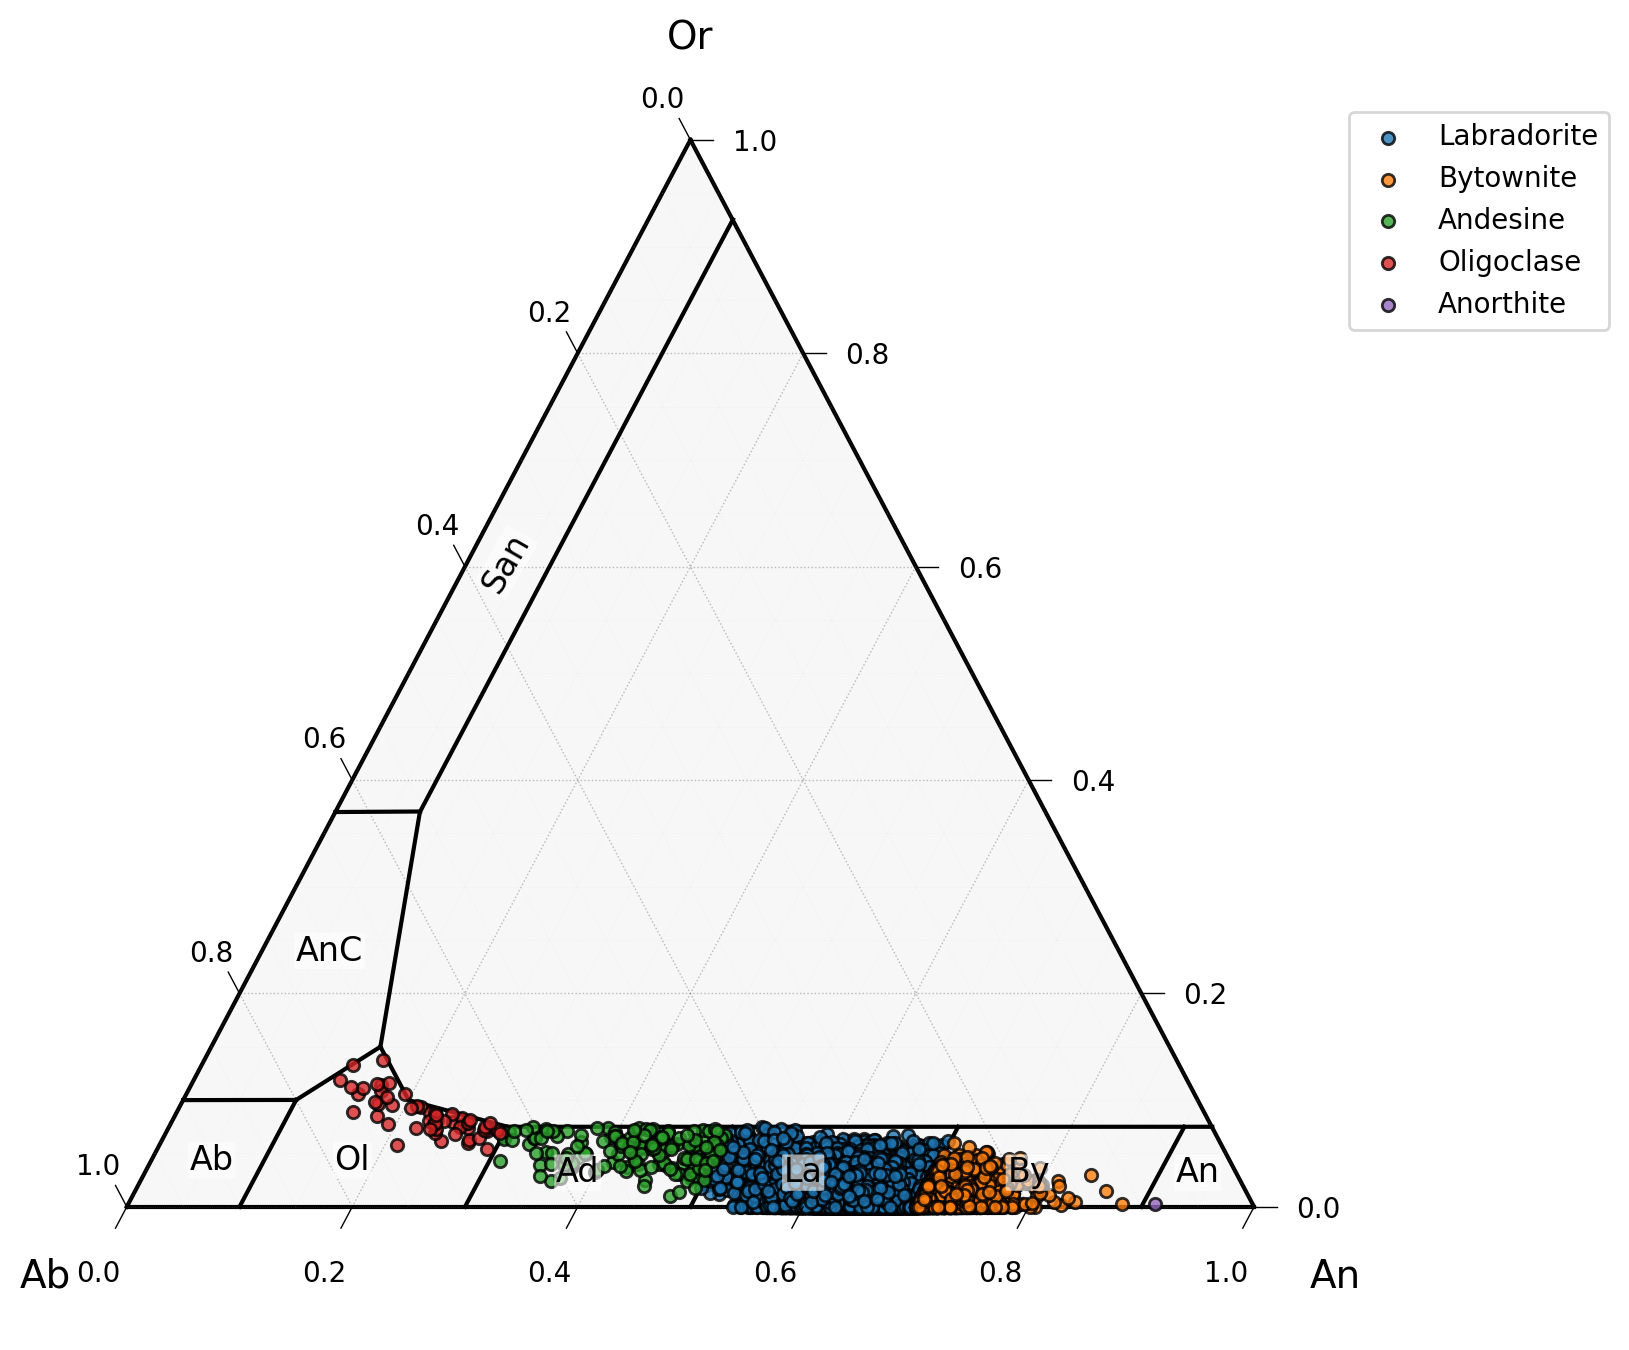

In [8]:
# Use Feldsparclassifier to examine at the component space (XAn, XAb, XOr)
fspar_comp = mm.FeldsparClassifier(fspars).calculate_components()
display(fspar_comp)


# Use FeldsparClassifier to plot up these data. 
fig = mm.FeldsparClassifier(fspars).plot()



,Sample Name,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,...,EnFs,DiHd_2003,Di,Fe3_Wang21,Fe2_Wang21,Di_h,Hd_h,Aeg_h,Jd_h,En_h
49,NaN,46.703956,2.306829,8.091728,7.608155,0.179336,10.411849,18.795262,2.432519,0.532825,...,0.086829,0.666407,0.469393,0.089679,0.154568,0.595819,0.009059,0.115772,0.018559,0.034919
610,NaN,48.659501,1.695958,7.334367,7.926977,0.000000,10.416438,17.438423,2.285797,1.183322,...,0.107573,0.632821,0.443486,0.013317,0.240387,0.594261,0.014598,0.071088,0.104224,0.066707
616,NaN,48.778790,1.189971,2.368374,9.717480,0.000000,19.703388,16.359033,0.808957,0.195681,...,0.417242,0.575877,0.451074,0.155597,0.150052,0.457241,0.000000,0.033339,0.000000,0.323735
626,NaN,43.817565,1.304287,4.129765,5.646358,0.000000,11.766227,22.258578,1.406237,0.008721,...,0.015722,0.891255,0.702211,0.187016,0.008697,0.726986,0.114188,0.062239,0.000000,0.000000
900,NaN,48.447279,1.397534,3.416259,9.859029,0.064421,16.668941,17.343585,1.357627,0.303317,...,0.317609,0.617466,0.462866,0.180335,0.131760,0.522099,0.000000,0.068710,0.000000,0.213817
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93026,NaN,48.531633,1.086635,6.924229,5.679027,0.897636,13.753107,20.414549,0.316232,0.073446,...,0.135029,0.681486,0.537139,-0.004870,0.183839,0.683252,0.000000,0.000000,0.000000,0.148472
93027,NaN,46.290230,1.380040,7.945115,7.235223,0.274338,11.797178,19.396081,0.955456,0.000000,...,0.131225,0.653965,0.481823,0.026500,0.208089,0.634156,0.000000,0.019312,0.000000,0.125825
93028,NaN,48.117886,0.149082,8.696416,5.671712,0.169030,13.621192,20.402754,1.625494,0.058249,...,0.125932,0.684517,0.551743,0.128591,0.048722,0.597250,0.000000,0.116397,0.000000,0.083585
93029,NaN,46.544554,0.287509,7.870030,6.250091,0.117071,12.650849,19.429830,0.000000,0.135432,...,0.162218,0.623032,0.485826,-0.043900,0.249511,0.639871,0.000000,0.000000,0.000000,0.155748


/Users/sarahcshi/opt/anaconda3/envs/science/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


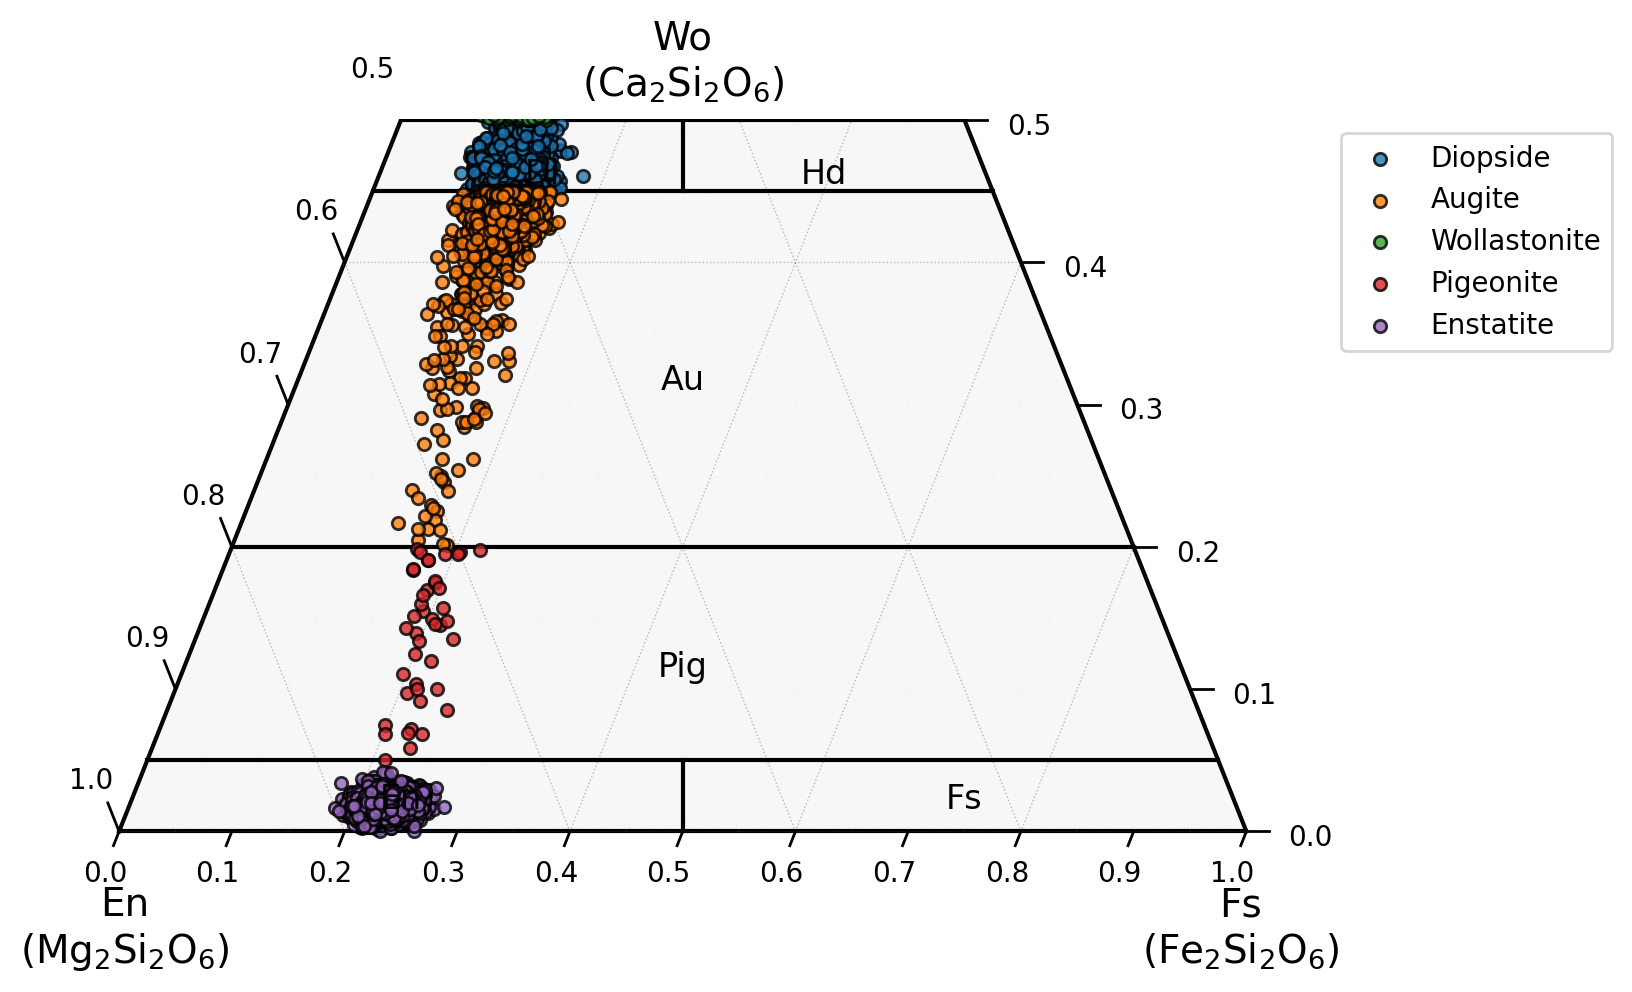

In [9]:
# Use Feldsparclassifier to examine at the component space (En, Wo, Fs). If sodic pyroxenes are also within this input, this will plot them up in the sodic pyroxene ternary
pxs_comp = mm.PyroxeneClassifier(pxs).calculate_components()
display(pxs_comp)

# Use PyroxeneClassifier to plot up these data. 
fig = mm.PyroxeneClassifier(pxs).plot()


,SiO2,TiO2,Al2O3,FeOt,MnO,MgO,CaO,Na2O,K2O,P2O5,...,Cation_Sum,A_site,A_site_expanded,B_site,A_B_site,Fe_Ti,Fe3_prop,XR2,XR3,XTi
597,0.000000,0.000000,59.577095,22.761509,0.261160,16.543655,0.178530,0.000000,0.000000,NaN,...,3.0,0.989221,0.995001,2.000000,2.995001,0.497456,0.307035,0.332221,0.667779,0.000000
598,0.328607,0.192199,60.074062,22.531151,0.000000,16.206175,0.000000,0.404589,0.000000,NaN,...,3.0,0.971775,0.971775,1.999551,2.971326,0.489140,0.280194,0.327051,0.671696,0.001254
599,0.419032,0.000000,59.597162,20.757558,0.000000,16.481142,0.000000,0.094932,0.114364,NaN,...,3.0,0.993664,0.993664,1.986631,2.980295,0.456697,0.239540,0.333411,0.666589,0.000000
879,0.000000,0.000000,58.807763,21.683161,0.131220,15.814531,0.000000,0.445707,0.113306,NaN,...,3.0,0.943236,0.946200,2.026900,2.973100,0.483592,0.349607,0.318254,0.681746,0.000000
881,0.082835,0.000000,59.493695,20.211482,0.000000,15.916152,0.157949,0.000000,0.121678,NaN,...,3.0,0.989397,0.989397,1.999721,2.989118,0.451609,0.212884,0.331000,0.669000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92992,0.000000,0.199933,61.268541,19.730463,0.777305,16.862860,0.416785,0.532657,0.209819,NaN,...,3.0,0.909033,0.925878,2.029424,2.955302,0.426036,0.370311,0.313294,0.685404,0.001302
92993,0.000000,0.000000,58.986714,21.457833,0.307136,14.984843,0.000000,0.000000,0.000000,NaN,...,3.0,0.992954,1.000000,2.000000,3.000000,0.486031,0.201826,0.333333,0.666667,0.000000
92994,0.000000,0.326008,59.845682,20.725138,0.091979,16.190988,0.066551,0.394945,0.127746,NaN,...,3.0,0.953691,0.955739,2.017969,2.973708,0.462154,0.299782,0.321396,0.676435,0.002168
92995,5.724564,0.254216,55.985948,19.883002,0.000000,15.163671,0.563598,1.013702,0.281037,NaN,...,3.0,1.017350,1.017350,1.756704,2.774054,0.439204,0.016451,0.366738,0.631462,0.001800


/Users/sarahcshi/opt/anaconda3/envs/science/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


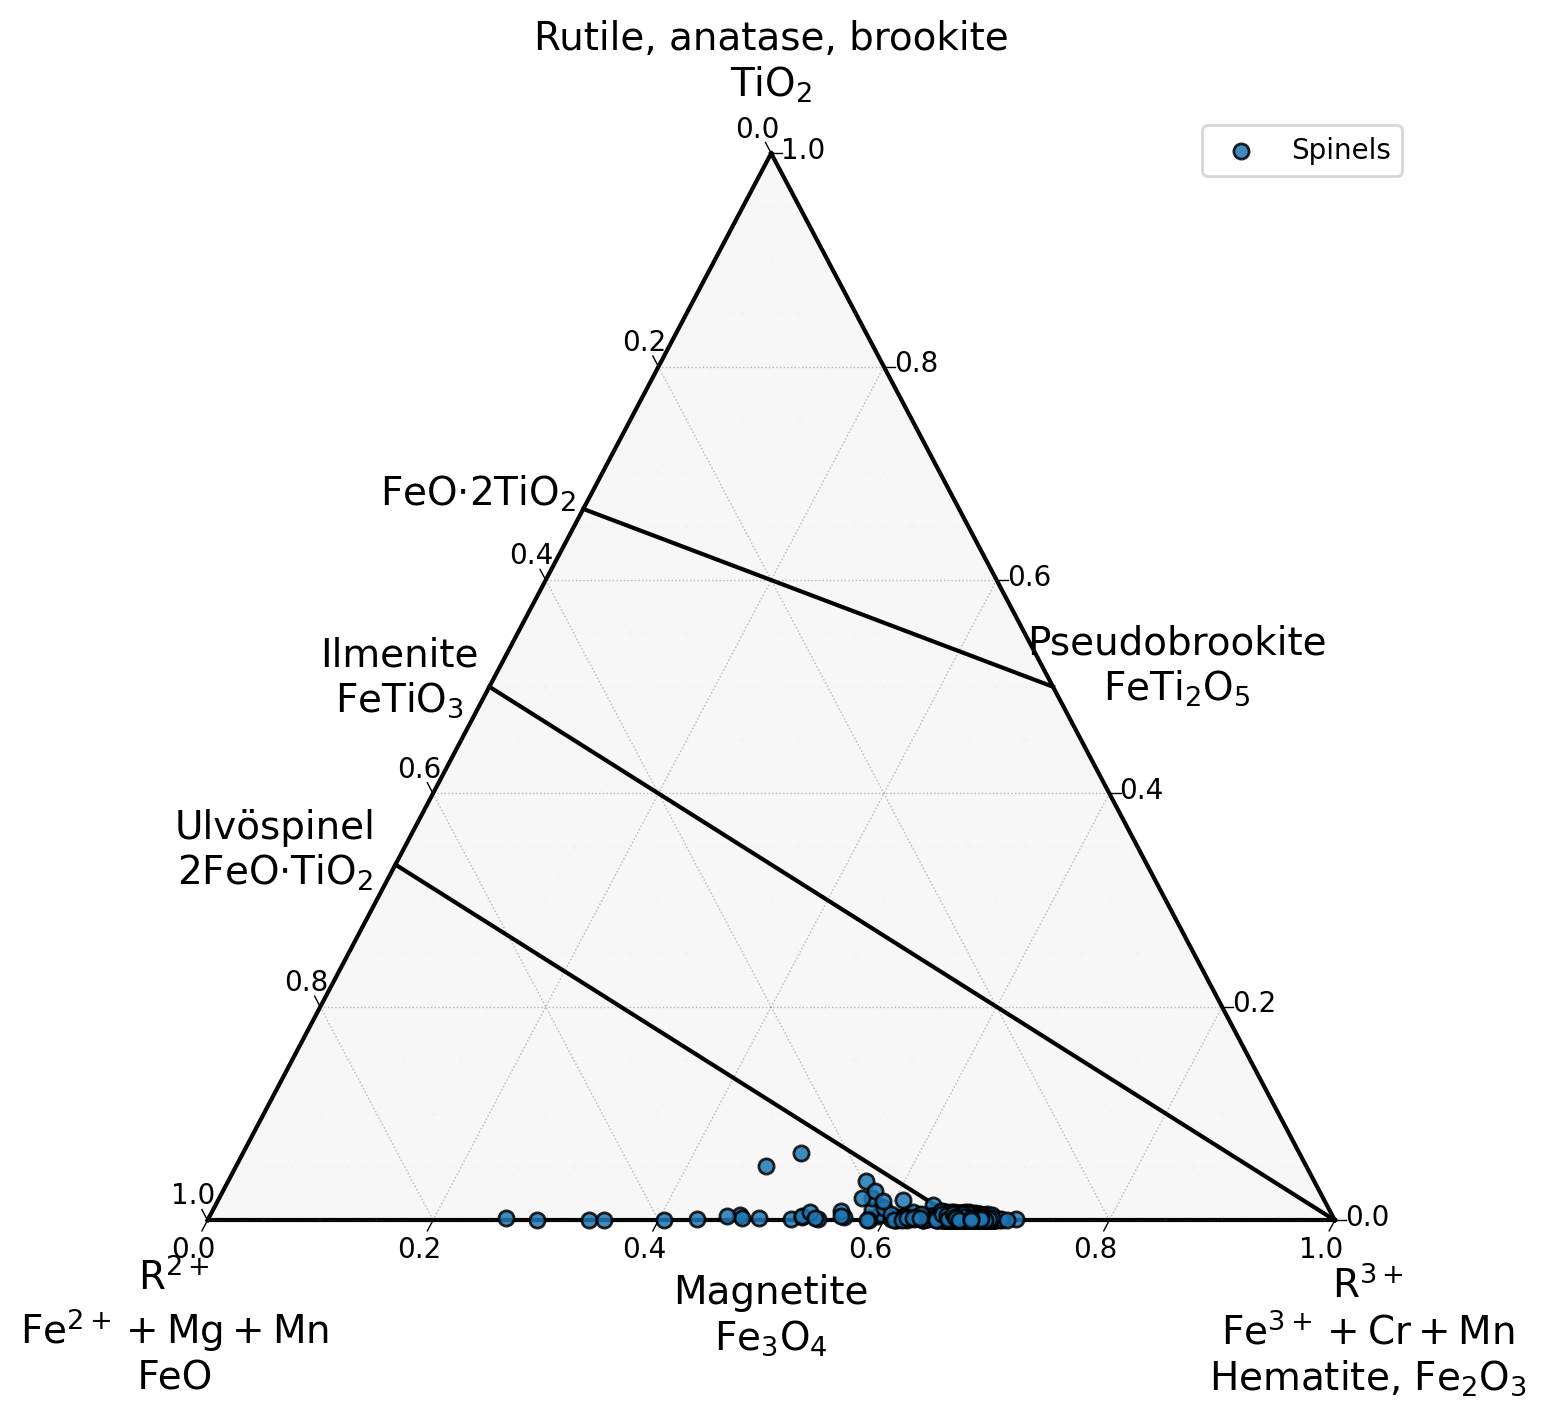

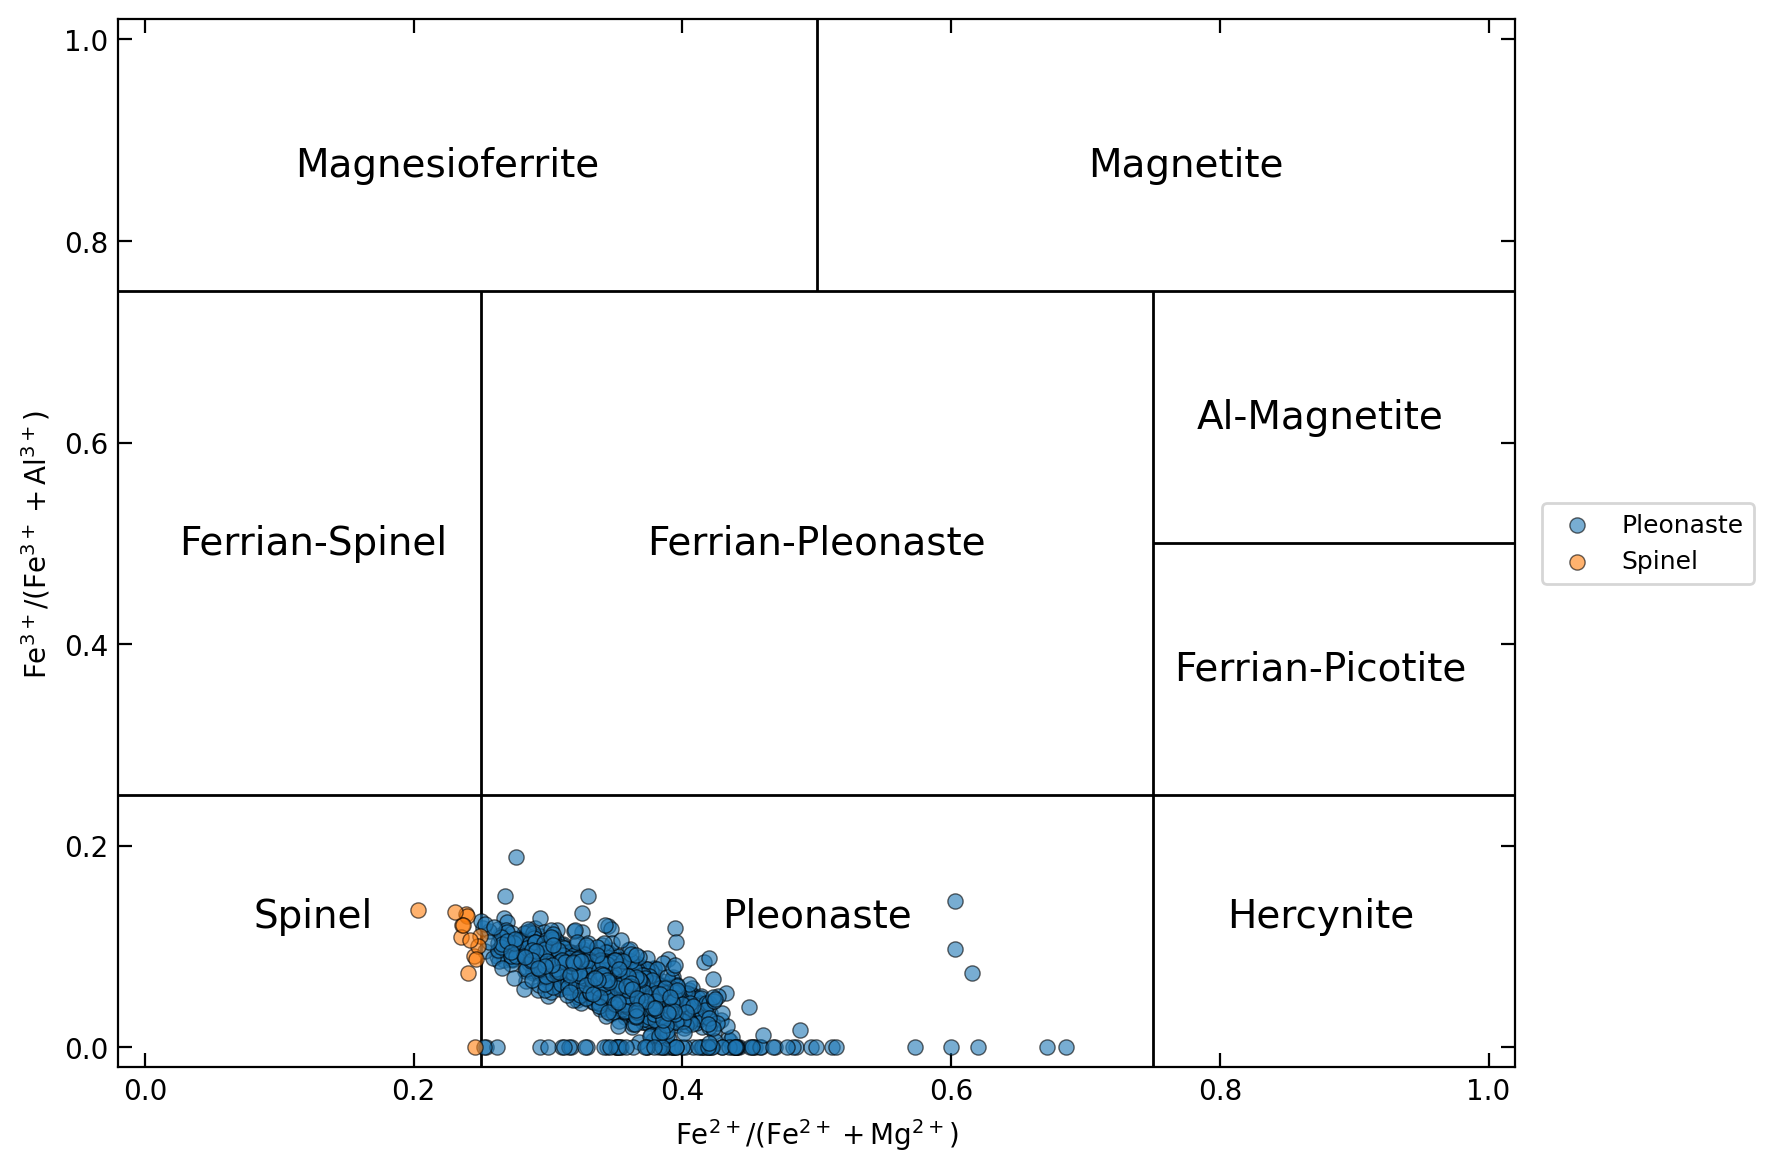

In [10]:
# Use OxideClassifier to examine at the component space.
sps_comp = mm.OxideClassifier(sps).calculate_components()
display(sps_comp)

# Use OxideClassifier to plot up these data. 
fig = mm.OxideClassifier(sps).plot()


You might note that the structure of these three ``...Classifier`` classes is identical. That is intentional! ``mm.FeldsparClassifier``, ``mm.PyroxeneClassifier``, and ``mm.OxideClassifier`` all have  `calculate_components` and `plot` methods embedded. 

### We know the mineralogy now. What if you now want to inspect the chemical variation within the individual crystals? Pull the component maps created for each sample and plot this up with ``mm.plot_component_composite``

This function currently does this calculation for feldspars, pyroxenes, and olivines as these are the most common phases I work with. This can easily be expanded with all the stoichiometric mineral functions. Here, I will just show this for these common igneous phases. 

['Clinopyroxene.En', 'Clinopyroxene.Fs', 'Clinopyroxene.Wo', 'Clinopyroxene.XMg', 'Feldspar.Ab', 'Feldspar.An', 'Feldspar.Or', 'Olivine.XFo', 'Orthopyroxene.En', 'Orthopyroxene.Fs', 'Orthopyroxene.Wo', 'Orthopyroxene.XMg']


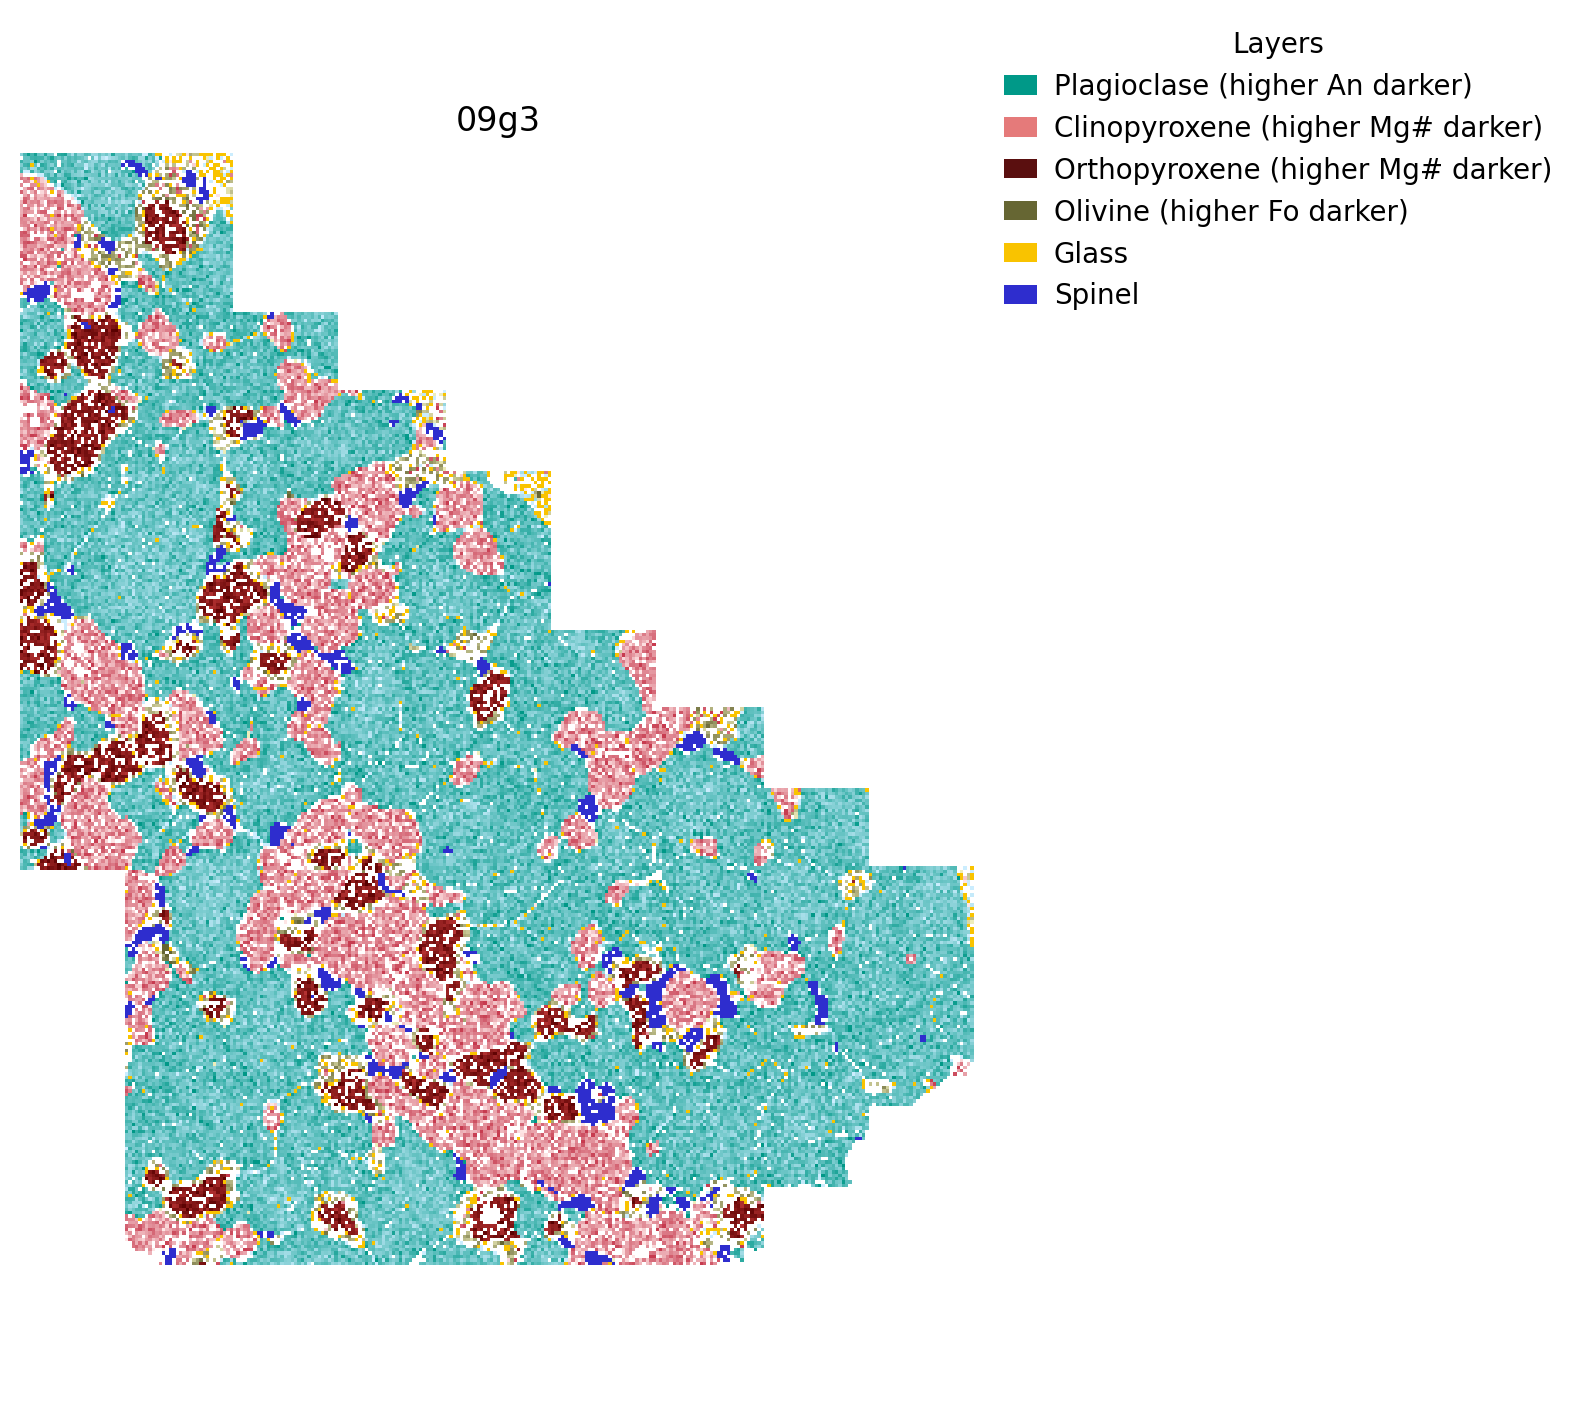

In [11]:
# Inspect what’s available:
print(sorted(output["component_maps"].keys()))

#  Plot map highlighting internal compositional variation
fig = mm.plot_component_composite(output,
                                  name="09g3",
                                  smooth_sigma=0.25,
                                  )


One could alternatively use all the functions within mineralML.mapping to do these same things, in a more stepwise manner. Look through the documentation if you would like to use individual bits of this code. 